# Notebook 4: PyTorch Fundamentals & Autograd

## "You built autograd from scratch. Now meet PyTorch's version."

In Series 1 Notebook 1, you built a `Value` class that tracked operations on scalars,
built a computation graph, and computed gradients via reverse-mode automatic differentiation.
You then assembled `Neuron`, `Layer`, and `MLP` classes and trained a network on the moons dataset.

**Now we do the same things -- but with PyTorch.** At every step we'll compare:
*"Remember when you built this by hand? Here's how PyTorch handles it."*

### What this notebook covers
1. **Tensors** -- PyTorch's fundamental data structure (think: NumPy arrays + GPU + autograd)
2. **Autograd** -- the same chain-rule engine you built, but industrial-strength
3. **nn.Module** -- the building block for neural networks
4. **Training loops** -- the canonical forward -> loss -> backward -> step pattern
5. **Universal Approximation in PyTorch** -- shallow-wide vs deep-narrow
6. **Custom Autograd Functions** -- when you need to define your own forward/backward

### Curriculum points covered
| # | Point | Where |
|---|-------|-------|
| ① | Universal Approximation Theorem | §6 |
| ② | ReLU changed everything | §3, §4 |
| ⑤ | Backpropagation = chain rule | §3 |


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Plotting defaults
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")


PyTorch version: 2.2.1
CUDA available:  False


---
## 2. Tensors -- PyTorch's Fundamental Data Structure

Remember working with NumPy arrays in the pure-Python notebooks?
PyTorch **tensors** are almost identical -- same shapes, same broadcasting rules,
same slicing -- but they add two super-powers:

1. **Autograd**: tensors can track every operation so gradients flow automatically.
2. **GPU acceleration**: tensors can live on a GPU for massive parallelism.

Let's explore.


### 2.1 Creating Tensors

In [2]:
# Creating tensors
# From Python lists
a = torch.tensor([1.0, 2.0, 3.0])
print("From list:       ", a, "  dtype:", a.dtype)

# From NumPy
np_arr = np.array([[1, 2], [3, 4]], dtype=np.float32)
b = torch.from_numpy(np_arr)
print("From NumPy:\n", b)

# Common constructors
print("\nzeros:  ", torch.zeros(2, 3))
print("ones:   ", torch.ones(2, 3))
print("randn:  ", torch.randn(2, 3))    # standard normal
print("arange: ", torch.arange(0, 1, 0.2))
print("eye:    ", torch.eye(3))

# Specifying dtype
c = torch.tensor([1, 2, 3], dtype=torch.float64)
print("\nfloat64 tensor:", c, "  dtype:", c.dtype)


From list:        tensor([1., 2., 3.])   dtype: torch.float32
From NumPy:
 tensor([[1., 2.],
        [3., 4.]])

zeros:   tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones:    tensor([[1., 1., 1.],
        [1., 1., 1.]])
randn:   tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])
arange:  tensor([0.0000, 0.2000, 0.4000, 0.6000, 0.8000])
eye:     tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

float64 tensor: tensor([1., 2., 3.], dtype=torch.float64)   dtype: torch.float64


### 2.2 Tensor Operations

These should feel familiar -- they mirror NumPy almost exactly.

In [3]:
# Basic arithmetic
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

print("x + y      =", x + y)           # element-wise add
print("x * y      =", x * y)           # element-wise mul (Hadamard)
print("x @ y      =", x @ y)           # dot product
print("x ** 2     =", x ** 2)          # element-wise power

# Matrix multiplication
A = torch.randn(2, 3)
B = torch.randn(3, 4)
C = A @ B                              # same as torch.matmul(A, B)
print(f"\nA shape: {A.shape}, B shape: {B.shape}, A@B shape: {C.shape}")


x + y      = tensor([5., 7., 9.])
x * y      = tensor([ 4., 10., 18.])
x @ y      = tensor(32.)
x ** 2     = tensor([1., 4., 9.])

A shape: torch.Size([2, 3]), B shape: torch.Size([3, 4]), A@B shape: torch.Size([2, 4])


In [4]:
# Reshaping
t = torch.arange(12, dtype=torch.float32)
print("Original:    ", t.shape)

t2 = t.reshape(3, 4)                   # reshape (like np.reshape)
print("reshape(3,4):", t2.shape)

t3 = t.view(2, 6)                      # view -- same data, new shape
print("view(2,6):   ", t3.shape)

t4 = t2.T                              # transpose
print("Transpose:   ", t4.shape)

# Unsqueeze / squeeze -- add or remove dimensions of size 1
t5 = t.unsqueeze(0)                    # (12,) -> (1, 12)
print("unsqueeze(0):", t5.shape)
t6 = t5.squeeze(0)                     # (1, 12) -> (12,)
print("squeeze(0):  ", t6.shape)


Original:     torch.Size([12])
reshape(3,4): torch.Size([3, 4])
view(2,6):    torch.Size([2, 6])
Transpose:    torch.Size([4, 3])
unsqueeze(0): torch.Size([1, 12])
squeeze(0):   torch.Size([12])


In [5]:
# Broadcasting
# Same rules as NumPy: dimensions are compared right-to-left,
# sizes must match or one of them must be 1.

mat = torch.ones(3, 4)
vec = torch.tensor([1.0, 2.0, 3.0, 4.0])   # shape (4,)

result = mat + vec     # vec is broadcast across rows
print("mat (3x4) + vec (4,):")
print(result)
print("Result shape:", result.shape)


mat (3x4) + vec (4,):
tensor([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]])
Result shape: torch.Size([3, 4])


### 2.3 NumPy <-> PyTorch

They share the same underlying memory (on CPU), so conversion is free.


In [6]:
# NumPy <-> Tensor (shared memory on CPU)
np_arr = np.array([1.0, 2.0, 3.0])
t = torch.from_numpy(np_arr)

print("NumPy array:", np_arr)
print("Torch tensor:", t)

# Modify one -> the other changes too (shared memory!)
np_arr[0] = 99.0
print("\nAfter changing np_arr[0] to 99:")
print("  NumPy:", np_arr)
print("  Torch:", t, "  <- also changed!")

# Going back to NumPy
t2 = torch.tensor([10.0, 20.0, 30.0])
np_arr2 = t2.numpy()
print("\nTensor -> NumPy:", np_arr2)


NumPy array: [1. 2. 3.]
Torch tensor: tensor([1., 2., 3.], dtype=torch.float64)

After changing np_arr[0] to 99:
  NumPy: [99.  2.  3.]
  Torch: tensor([99.,  2.,  3.], dtype=torch.float64)   <- also changed!

Tensor -> NumPy: [10. 20. 30.]


---
## 3. Autograd -- "Backprop is just the chain rule"

> **⑤ Curriculum Point: Backpropagation = Chain Rule**
>
> In Notebook 1, you implemented `backward()` yourself: topological sort of the
> computation graph, then propagate gradients node-by-node using the chain rule.
> PyTorch does **exactly the same thing** -- but automatically, for tensors of any shape.
> Every `torch` operation records itself into a dynamic computation graph.
> When you call `.backward()`, PyTorch walks that graph in reverse.


### 3.1 requires_grad and .backward()

In [7]:
# requires_grad tells PyTorch: "track this tensor"
# Remember in your Value class, every Value tracked _prev and _op?
# In PyTorch, setting requires_grad=True does the same thing.

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Build a computation: z = x^2 * y + y^3
# In your Value class this would be:
#   x = Value(2.0); y = Value(3.0)
#   z = x**2 * y + y**3
z = x**2 * y + y**3

print(f"z = x^2*y + y^3 = {x.item()}^2*{y.item()} + {y.item()}^3 = {z.item()}")
print(f"z.grad_fn: {z.grad_fn}")   # shows the last operation

# Backward pass -- just like your z.backward()!
z.backward()

print(f"\ndz/dx = 2xy = 2*{x.item()}*{y.item()} = {x.grad.item()}")
print(f"  PyTorch computed: {x.grad.item()} check!")

print(f"\ndz/dy = x^2 + 3y^2 = {x.item()}^2 + 3*{y.item()}^2 = {y.grad.item()}")
print(f"  PyTorch computed: {y.grad.item()} check!")


z = x^2*y + y^3 = 2.0^2*3.0 + 3.0^3 = 39.0
z.grad_fn: <AddBackward0 object at 0x13e607df0>

dz/dx = 2xy = 2*2.0*3.0 = 12.0
  PyTorch computed: 12.0 check!

dz/dy = x^2 + 3y^2 = 2.0^2 + 3*3.0^2 = 31.0
  PyTorch computed: 31.0 check!


### 3.2 Gradient Verification -- Matching Your Hand-Built Engine

Let's compute the same expression we used in Notebook 1 and verify PyTorch
gets the same gradients.


In [8]:
# Same expression as pure-Python notebook
# Expression: f(a,b) = (a + b) * (b + 1)
# df/da = b + 1
# df/db = a + 2b + 1

a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

f = (a + b) * (b + 1.0)
f.backward()

# Analytical gradients
df_da_analytical = b.item() + 1       # = 4.0
df_db_analytical = a.item() + 2*b.item() + 1  # = 9.0

print("Expression: f(a,b) = (a + b) * (b + 1)")
print(f"  a = {a.item()}, b = {b.item()}, f = {f.item()}")
match_a = "MATCH" if abs(a.grad.item() - df_da_analytical) < 1e-6 else "MISMATCH"
match_b = "MATCH" if abs(b.grad.item() - df_db_analytical) < 1e-6 else "MISMATCH"
print(f"\n  df/da: PyTorch = {a.grad.item():.4f}, Analytical = {df_da_analytical:.4f}  [{match_a}]")
print(f"  df/db: PyTorch = {b.grad.item():.4f}, Analytical = {df_db_analytical:.4f}  [{match_b}]")


Expression: f(a,b) = (a + b) * (b + 1)
  a = 2.0, b = 3.0, f = 20.0

  df/da: PyTorch = 4.0000, Analytical = 4.0000  [MATCH]
  df/db: PyTorch = 9.0000, Analytical = 9.0000  [MATCH]


### 3.3 Visualizing the Computation Graph

In Notebook 1 you built a text-based graph. PyTorch stores the graph in the `.grad_fn`
chain. Let's trace it.


In [9]:
# Walking the computation graph
# Each tensor produced by an operation has a .grad_fn that points back
# to the operation that created it, and .next_functions pointing to inputs.

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = x * y + x**2

def trace_graph_fn(fn, indent=0):
    """Trace from a grad_fn node."""
    prefix = "  " * indent
    print(f"{prefix}{fn}")
    for child, _ in fn.next_functions:
        if child is not None:
            trace_graph_fn(child, indent + 1)
        else:
            print(f"{'  ' * (indent+1)}(leaf tensor)")

def trace_graph(tensor, indent=0):
    """Recursively print the computation graph (like your text visualization)."""
    prefix = "  " * indent
    if tensor.grad_fn:
        print(f"{prefix}{tensor.grad_fn}")
        for child, _ in tensor.grad_fn.next_functions:
            if child is not None:
                trace_graph_fn(child, indent + 1)
            else:
                name = "(leaf tensor)"
                print(f"{'  ' * (indent+1)}{name}")
    else:
        name = "leaf"
        if tensor.requires_grad:
            name = f"leaf (requires_grad, data={tensor.item():.1f})"
        print(f"{prefix}{name}")

print("Computation graph for z = x*y + x^2:")
print("=" * 50)
trace_graph(z)


Computation graph for z = x*y + x^2:


### 3.4 torch.no_grad() -- When and Why

During **inference** (making predictions), we don't need gradients.
`torch.no_grad()` disables gradient tracking for efficiency.

> **Remember**: In your pure-Python Value class, every operation created
> new nodes in the graph. That's expensive! In production, you only want
> to build the graph during training.


In [10]:
# torch.no_grad()
x = torch.randn(1000, 1000, requires_grad=True)

# With gradient tracking (training mode)
import time
start = time.time()
for _ in range(10):
    y = x @ x.T
grad_time = time.time() - start

# Without gradient tracking (inference mode)
start = time.time()
with torch.no_grad():
    for _ in range(10):
        y = x @ x.T
no_grad_time = time.time() - start

print(f"With grad tracking:    {grad_time:.4f}s")
print(f"Without (no_grad):     {no_grad_time:.4f}s")
if no_grad_time > 0:
    print(f"Speedup:               {grad_time / no_grad_time:.1f}x")


With grad tracking:    0.0129s
Without (no_grad):     0.0118s
Speedup:               1.1x


> **⑤ Key Insight: Backprop is just the chain rule -- and PyTorch automates it**
>
> You implemented every `_backward` closure by hand in Notebook 1.
> PyTorch has hundreds of these registered for every tensor operation.
> When you call `.backward()`, it does exactly what your code did:
> 1. Topological sort the computation graph
> 2. Walk it in reverse
> 3. Accumulate gradients using the chain rule
>
> The only difference? PyTorch handles tensors of any shape, runs on GPU,
> and is battle-tested by millions of users.


---
## 4. Building an MLP with `nn.Module`

In Notebook 1 you built `Neuron`, `Layer`, and `MLP` classes from scratch.
Each Neuron held `Value` weights and a bias. Here's the PyTorch way.

> **② Curriculum Point: ReLU Changed Everything**
>
> In your pure-Python notebook, you saw that sigmoid squashes gradients
> toward zero in deep networks. ReLU passes gradients through unchanged
> (gradient is 0 or 1). This is why virtually all modern networks use ReLU
> or its variants. We'll use `nn.ReLU` throughout.


### 4.1 nn.Linear and nn.ReLU

In [11]:
# nn.Linear: the PyTorch equivalent of your Neuron/Layer
# Your Layer class: each neuron had weights (Value objects) and a bias
# nn.Linear(in_features, out_features) does the same thing: y = Wx + b

layer = nn.Linear(in_features=3, out_features=2)

print("Weight shape:", layer.weight.shape)   # (out, in) = (2, 3)
print("Bias shape:  ", layer.bias.shape)     # (out,) = (2,)
print("\nWeight:\n", layer.weight.data)
print("Bias:", layer.bias.data)

# Forward pass on a batch of 4 samples, each with 3 features
x = torch.randn(4, 3)
out = layer(x)      # calls layer.forward(x) -> x @ W.T + b
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {out.shape}")


Weight shape: torch.Size([2, 3])
Bias shape:   torch.Size([2])

Weight:
 tensor([[-0.0282, -0.0377, -0.2000],
        [ 0.3835, -0.3681, -0.0933]])
Bias: tensor([ 0.0564, -0.0512])

Input shape:  torch.Size([4, 3])
Output shape: torch.Size([4, 2])


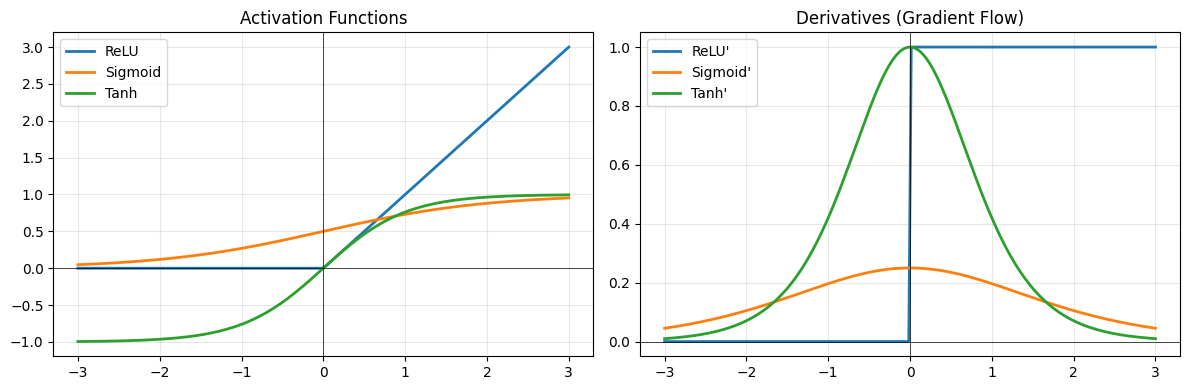

Notice: Sigmoid derivative maxes out at 0.25.
Chain 10 layers: 0.25^10 = 9.5367431640625e-07
ReLU derivative is exactly 1 (for x > 0) -- no vanishing gradient!


In [12]:
# nn.ReLU vs nn.Sigmoid
# Remember: ReLU changed everything because its gradient is 0 or 1.
# No vanishing gradient!

x = torch.linspace(-3, 3, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Functions
axes[0].plot(x.numpy(), torch.relu(x).numpy(), label='ReLU', linewidth=2)
axes[0].plot(x.numpy(), torch.sigmoid(x).numpy(), label='Sigmoid', linewidth=2)
axes[0].plot(x.numpy(), torch.tanh(x).numpy(), label='Tanh', linewidth=2)
axes[0].set_title('Activation Functions')
axes[0].legend()
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

# Derivatives
# For ReLU: derivative is 1 if x > 0, else 0
relu_grad = (x > 0).float()
# For sigmoid: s'(x) = s(x)(1 - s(x))
sig = torch.sigmoid(x)
sig_grad = sig * (1 - sig)
# For tanh: tanh'(x) = 1 - tanh^2(x)
tanh_val = torch.tanh(x)
tanh_grad = 1 - tanh_val**2

axes[1].plot(x.numpy(), relu_grad.numpy(), label="ReLU'", linewidth=2)
axes[1].plot(x.numpy(), sig_grad.numpy(), label="Sigmoid'", linewidth=2)
axes[1].plot(x.numpy(), tanh_grad.numpy(), label="Tanh'", linewidth=2)
axes[1].set_title('Derivatives (Gradient Flow)')
axes[1].legend()
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("Notice: Sigmoid derivative maxes out at 0.25.")
print("Chain 10 layers: 0.25^10 =", 0.25**10)
print("ReLU derivative is exactly 1 (for x > 0) -- no vanishing gradient!")


### 4.2 Building a Custom nn.Module

This is the PyTorch equivalent of your `MLP` class from Notebook 1.


In [13]:
# Custom MLP using nn.Module
# Remember your MLP class?
#   class MLP:
#       def __init__(self, nin, nouts):
#           sz = [nin] + nouts
#           self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
#       def __call__(self, x):
#           for layer in self.layers:
#               x = layer(x)
#           return x
#
# Here's the PyTorch equivalent:

class MLP(nn.Module):
    """Multi-Layer Perceptron, the PyTorch way."""

    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()

        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Create a model: 2 inputs -> [16, 16] hidden -> 1 output
model = MLP(input_dim=2, hidden_dims=[16, 16], output_dim=1)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")


MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 337


In [14]:
# Inspecting parameters
# Remember model.parameters() from your MLP? Same concept.

print("Named parameters:")
print("-" * 50)
for name, param in model.named_parameters():
    print(f"  {name:30s} shape={str(list(param.shape)):15s} #params={param.numel()}")

total = sum(p.numel() for p in model.parameters())
print(f"\n  {'TOTAL':30s} {'':15s} #params={total}")


Named parameters:
--------------------------------------------------
  network.0.weight               shape=[16, 2]         #params=32
  network.0.bias                 shape=[16]            #params=16
  network.2.weight               shape=[16, 16]        #params=256
  network.2.bias                 shape=[16]            #params=16
  network.4.weight               shape=[1, 16]         #params=16
  network.4.bias                 shape=[1]             #params=1

  TOTAL                                          #params=337


---
## 5. Training Loop

In Notebook 1, your training loop looked like this:
```python
for step in range(steps):
    # Forward pass
    ypred = [model(x) for x in xs]
    loss = sum((yp - yt)**2 for yp, yt in zip(ypred, ys))

    # Backward pass
    for p in model.parameters():
        p.grad = 0.0
    loss.backward()

    # Update
    for p in model.parameters():
        p.data -= learning_rate * p.grad
```

The PyTorch version follows the **exact same pattern**, just using PyTorch's tools.


### 5.1 Loss Functions and Optimizers

In [15]:
# Loss functions
# Your pure-python loss: sum of squared errors computed manually
# PyTorch provides optimized, numerically stable versions

# Mean Squared Error (regression)
mse_loss = nn.MSELoss()
pred = torch.tensor([1.0, 2.0, 3.0])
target = torch.tensor([1.1, 2.2, 2.8])
print(f"MSE Loss: {mse_loss(pred, target).item():.4f}")

# Binary Cross-Entropy with Logits (binary classification)
bce_loss = nn.BCEWithLogitsLoss()
logits = torch.tensor([0.5, -1.0, 2.0])
labels = torch.tensor([1.0, 0.0, 1.0])
print(f"BCE Loss: {bce_loss(logits, labels).item():.4f}")

# Cross-Entropy (multi-class classification)
ce_loss = nn.CrossEntropyLoss()
logits_mc = torch.tensor([[2.0, 0.5, -1.0], [0.1, 3.0, 0.5]])  # 2 samples, 3 classes
labels_mc = torch.tensor([0, 1])  # correct classes
print(f"CE Loss:  {ce_loss(logits_mc, labels_mc).item():.4f}")


MSE Loss: 0.0300
BCE Loss: 0.3048
CE Loss:  0.1849


In [16]:
# Optimizers
# Your pure-python update: p.data -= lr * p.grad
# PyTorch optimizers do the same (and much more)

model_demo = MLP(input_dim=2, hidden_dims=[8], output_dim=1)

# SGD -- exactly what you implemented
sgd = optim.SGD(model_demo.parameters(), lr=0.01)

# Adam -- adaptive learning rates per parameter
adam = optim.Adam(model_demo.parameters(), lr=0.001)

print("SGD:  Simple gradient descent (what you built in Notebook 1)")
print("Adam: Adaptive lr per param (widely used in practice)")


SGD:  Simple gradient descent (what you built in Notebook 1)
Adam: Adaptive lr per param (widely used in practice)


### 5.2 Training on the Moons Dataset

Same dataset as Notebook 1! But now with PyTorch.


X shape: torch.Size([300, 2])
y shape: torch.Size([300, 1])


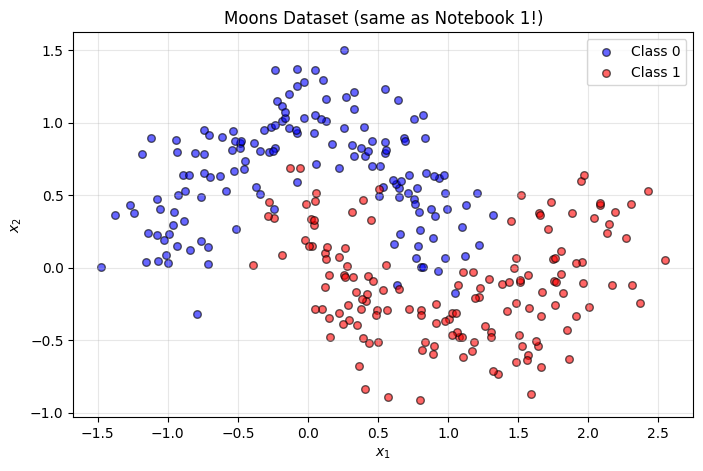

In [17]:
# Generate moons data
torch.manual_seed(42)
np.random.seed(42)

X_np, y_np = make_moons(n_samples=300, noise=0.2, random_state=42)

# Convert to PyTorch tensors
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)  # (300, 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], c='blue', label='Class 0', alpha=0.6, edgecolors='k', s=30)
plt.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], c='red', label='Class 1', alpha=0.6, edgecolors='k', s=30)
plt.title('Moons Dataset (same as Notebook 1!)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.show()


In [18]:
# Train the MLP
torch.manual_seed(42)

model = MLP(input_dim=2, hidden_dims=[16, 16], output_dim=1)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

losses = []
accuracies = []

for epoch in range(500):
    # -- Forward pass --
    logits = model(X)                   # raw scores
    loss = loss_fn(logits, y)           # compute loss

    # -- Backward pass --
    optimizer.zero_grad()               # zero gradients (like your p.grad = 0)
    loss.backward()                     # compute gradients (like your loss.backward())

    # -- Update parameters --
    optimizer.step()                    # update weights (like your p.data -= lr * p.grad)

    # -- Track metrics --
    with torch.no_grad():
        preds = (torch.sigmoid(logits) > 0.5).float()
        acc = (preds == y).float().mean().item()

    losses.append(loss.item())
    accuracies.append(acc)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Accuracy: {acc:.2%}")

print(f"\nFinal -- Loss: {losses[-1]:.4f} | Accuracy: {accuracies[-1]:.2%}")


Epoch   0 | Loss: 0.6946 | Accuracy: 50.00%
Epoch 100 | Loss: 0.1663 | Accuracy: 93.00%
Epoch 200 | Loss: 0.0618 | Accuracy: 97.67%
Epoch 300 | Loss: 0.0509 | Accuracy: 97.67%
Epoch 400 | Loss: 0.0489 | Accuracy: 97.67%

Final -- Loss: 0.0481 | Accuracy: 97.67%


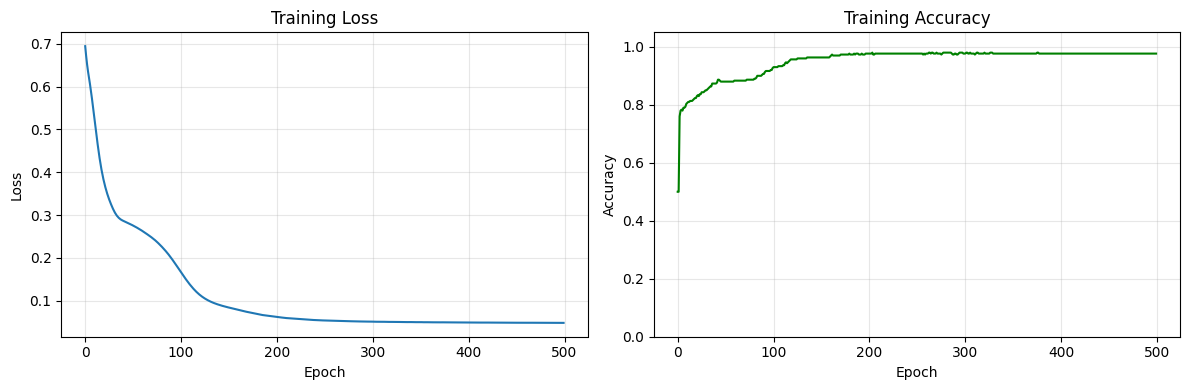

In [19]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, linewidth=1.5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')

ax2.plot(accuracies, linewidth=1.5, color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


### 5.3 Visualizing the Decision Boundary

Remember plotting this in Notebook 1? Same technique -- but now PyTorch makes
the forward pass trivial.


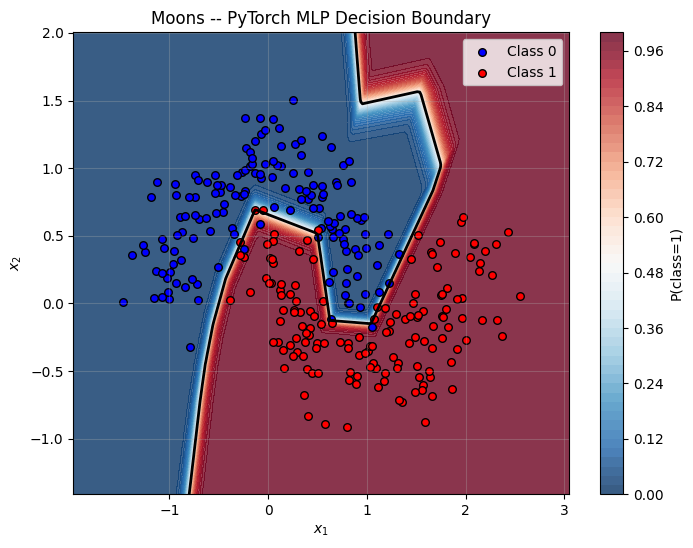

In [20]:
# Decision boundary visualization
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Plot the decision boundary of a binary classifier."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        probs = torch.sigmoid(model(grid)).numpy().reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.8)
    plt.colorbar(label='P(class=1)')
    plt.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=2)

    y_np = y.numpy().ravel()
    X_np = X.numpy()
    plt.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], c='blue',
                edgecolors='k', s=30, label='Class 0')
    plt.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], c='red',
                edgecolors='k', s=30, label='Class 1')
    plt.title(title)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.show()

plot_decision_boundary(model, X, y, "Moons -- PyTorch MLP Decision Boundary")


### 5.4 Decision Boundary Evolution During Training

Let's retrain and capture snapshots to see how the boundary evolves -- just like
the visualization in Notebook 1.


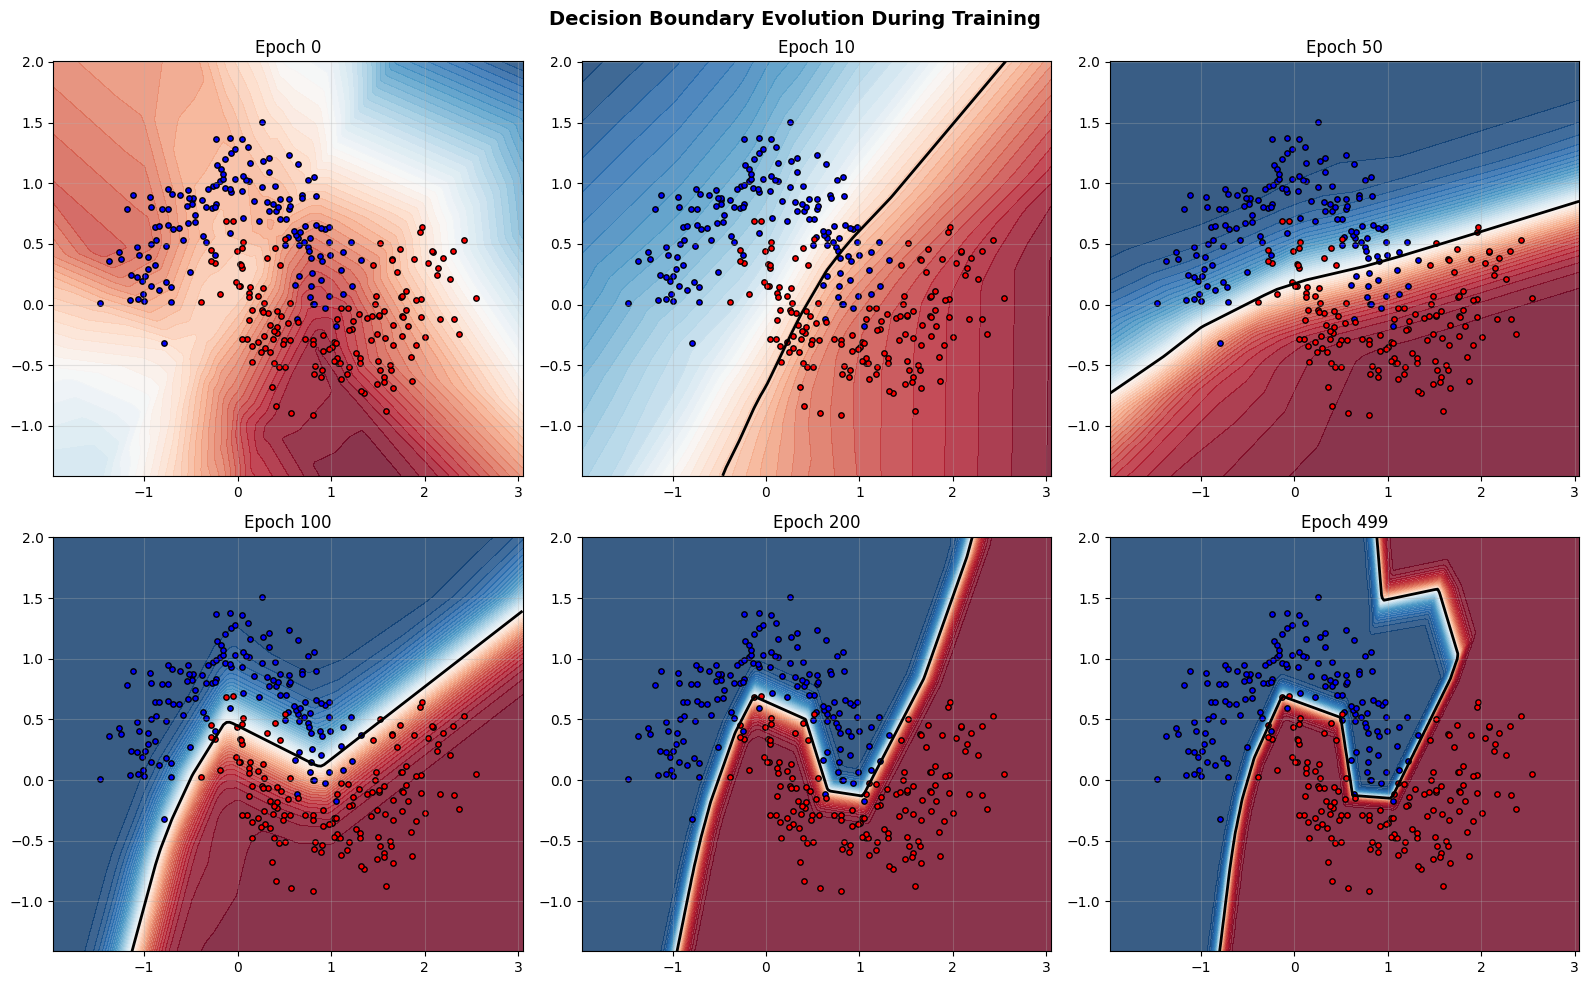

In [21]:
# Retrain with snapshots
torch.manual_seed(42)

model_snap = MLP(input_dim=2, hidden_dims=[16, 16], output_dim=1)
optimizer_snap = optim.Adam(model_snap.parameters(), lr=0.01)
loss_fn_snap = nn.BCEWithLogitsLoss()

# We'll save model state at key epochs
snapshot_epochs = [0, 10, 50, 100, 200, 499]
snapshots = {}

for epoch in range(500):
    if epoch in snapshot_epochs:
        # Save a copy of the model state
        snapshots[epoch] = {k: v.clone() for k, v in model_snap.state_dict().items()}

    logits = model_snap(X)
    loss = loss_fn_snap(logits, y)
    optimizer_snap.zero_grad()
    loss.backward()
    optimizer_snap.step()

# Plot snapshots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

temp_model = MLP(input_dim=2, hidden_dims=[16, 16], output_dim=1)

for idx, ep in enumerate(snapshot_epochs):
    temp_model.load_state_dict(snapshots[ep])
    with torch.no_grad():
        probs = torch.sigmoid(temp_model(grid)).numpy().reshape(xx.shape)

    ax = axes[idx]
    ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.8)
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=2)

    y_np_flat = y.numpy().ravel()
    X_np_arr = X.numpy()
    ax.scatter(X_np_arr[y_np_flat == 0, 0], X_np_arr[y_np_flat == 0, 1],
               c='blue', edgecolors='k', s=15)
    ax.scatter(X_np_arr[y_np_flat == 1, 0], X_np_arr[y_np_flat == 1, 1],
               c='red', edgecolors='k', s=15)
    ax.set_title(f'Epoch {ep}')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.suptitle('Decision Boundary Evolution During Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Universal Approximation in PyTorch

> **① Curriculum Point: Universal Approximation Theorem**
>
> In Notebook 1, you demonstrated that a single hidden layer with enough neurons
> can approximate any continuous function. And that a **deep narrow** network
> often does it more efficiently (fewer parameters).
>
> Let's repeat that experiment in PyTorch -- much easier now!


### 6.1 The Target Function

We'll fit $f(x) = \sin(x) \cdot \cos(3x)$ -- a complex, multi-frequency function.


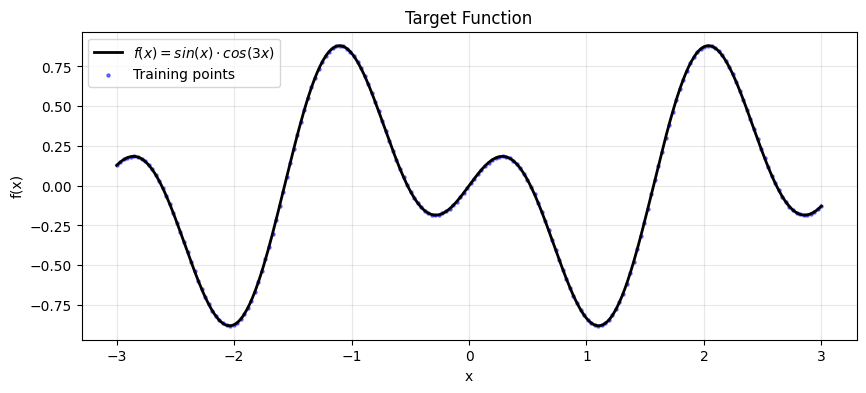

In [22]:
# Target function
torch.manual_seed(42)

def target_fn(x):
    return torch.sin(x) * torch.cos(3 * x)

# Training data
x_train = torch.linspace(-3, 3, 200).unsqueeze(1)   # (200, 1)
y_train = target_fn(x_train)

# Dense evaluation grid
x_eval = torch.linspace(-3, 3, 500).unsqueeze(1)
y_eval = target_fn(x_eval)

plt.figure(figsize=(10, 4))
plt.plot(x_eval.numpy(), y_eval.numpy(), 'k-', linewidth=2, label='$f(x) = sin(x) \cdot cos(3x)$')
plt.scatter(x_train.numpy(), y_train.numpy(), c='blue', s=5, alpha=0.5, label='Training points')
plt.title('Target Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()


### 6.2 Shallow-Wide vs Deep-Narrow

We'll train two networks:
- **Shallow-wide**: 1 hidden layer with 100 neurons
- **Deep-narrow**: 4 hidden layers with 10 neurons each

Both use ReLU. We'll compare how well they fit and how many parameters they use.


In [23]:
# Define both architectures
torch.manual_seed(42)

# Shallow-wide: 1 hidden layer, 100 neurons
shallow = nn.Sequential(
    nn.Linear(1, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
)

# Deep-narrow: 4 hidden layers, 10 neurons each
deep = nn.Sequential(
    nn.Linear(1, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)

shallow_params = sum(p.numel() for p in shallow.parameters())
deep_params = sum(p.numel() for p in deep.parameters())

print(f"Shallow-wide (1x100):  {shallow_params} parameters")
print(f"Deep-narrow  (4x10):   {deep_params} parameters")
print(f"\nDeep network uses {deep_params/shallow_params:.1%} of the shallow network's parameters")


Shallow-wide (1x100):  301 parameters
Deep-narrow  (4x10):   361 parameters

Deep network uses 119.9% of the shallow network's parameters


In [24]:
# Train both networks
def train_model(model, x, y, epochs=2000, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        pred = model(x)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

torch.manual_seed(42)
shallow_model = nn.Sequential(
    nn.Linear(1, 100), nn.ReLU(), nn.Linear(100, 1)
)
deep_model = nn.Sequential(
    nn.Linear(1, 10), nn.ReLU(),
    nn.Linear(10, 10), nn.ReLU(),
    nn.Linear(10, 10), nn.ReLU(),
    nn.Linear(10, 10), nn.ReLU(),
    nn.Linear(10, 1)
)

print("Training shallow-wide network...")
shallow_losses = train_model(shallow_model, x_train, y_train, epochs=3000, lr=0.005)
print(f"  Final loss: {shallow_losses[-1]:.6f}")

print("Training deep-narrow network...")
deep_losses = train_model(deep_model, x_train, y_train, epochs=3000, lr=0.005)
print(f"  Final loss: {deep_losses[-1]:.6f}")


Training shallow-wide network...
  Final loss: 0.003143
Training deep-narrow network...
  Final loss: 0.000091


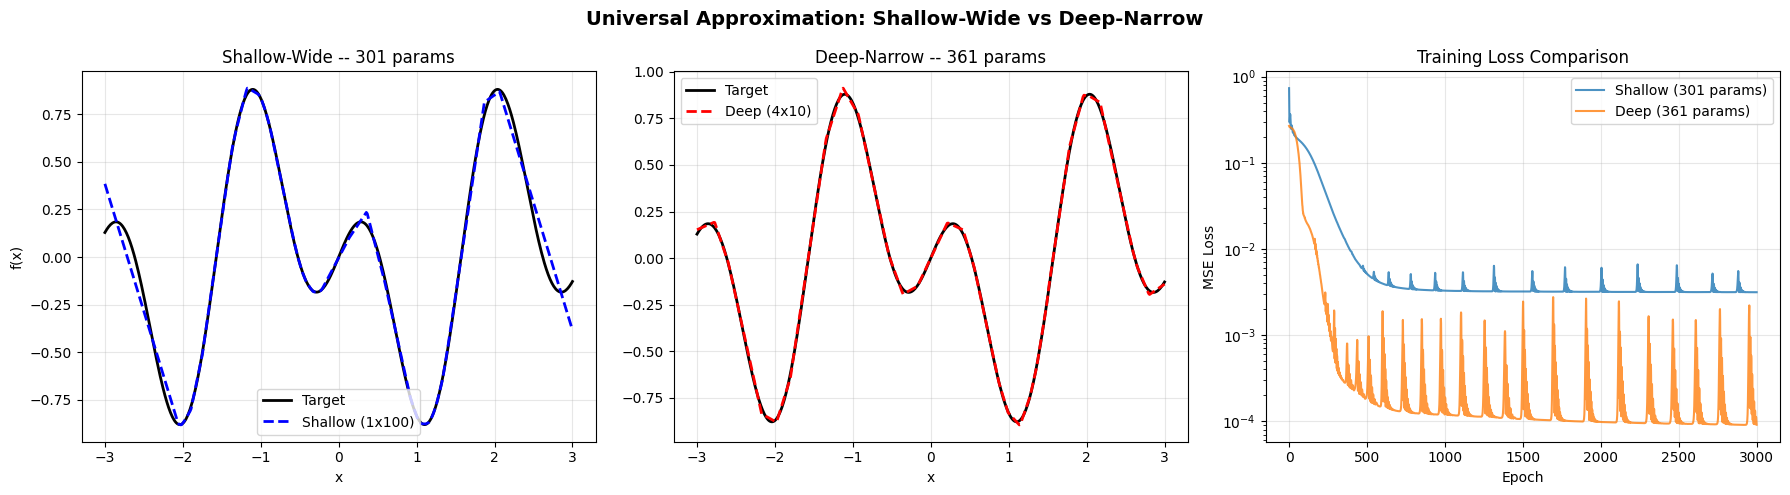

In [25]:
# Compare approximations
with torch.no_grad():
    y_shallow = shallow_model(x_eval).numpy()
    y_deep = deep_model(x_eval).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Shallow-wide fit
axes[0].plot(x_eval.numpy(), y_eval.numpy(), 'k-', linewidth=2, label='Target')
axes[0].plot(x_eval.numpy(), y_shallow, 'b--', linewidth=2, label='Shallow (1x100)')
shallow_nparams = sum(p.numel() for p in shallow_model.parameters())
axes[0].set_title(f'Shallow-Wide -- {shallow_nparams} params')
axes[0].legend()
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')

# Deep-narrow fit
axes[1].plot(x_eval.numpy(), y_eval.numpy(), 'k-', linewidth=2, label='Target')
axes[1].plot(x_eval.numpy(), y_deep, 'r--', linewidth=2, label='Deep (4x10)')
deep_nparams = sum(p.numel() for p in deep_model.parameters())
axes[1].set_title(f'Deep-Narrow -- {deep_nparams} params')
axes[1].legend()
axes[1].set_xlabel('x')

# Loss curves
axes[2].plot(shallow_losses, label=f'Shallow ({shallow_nparams} params)', alpha=0.8)
axes[2].plot(deep_losses, label=f'Deep ({deep_nparams} params)', alpha=0.8)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('Training Loss Comparison')
axes[2].set_yscale('log')
axes[2].legend()

plt.suptitle('Universal Approximation: Shallow-Wide vs Deep-Narrow',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


> **① Key Insight: Universal Approximation**
>
> Both networks can approximate the target function -- the Universal Approximation
> Theorem guarantees this for a single hidden layer with enough neurons.
>
> But notice: the **deep-narrow** network achieves comparable quality with
> **far fewer parameters**. Depth lets the network compose simple features
> into complex ones hierarchically. This is why modern networks are deep,
> not just wide.


---
## 7. Custom Autograd Function

Sometimes you need to define a custom operation with your own forward and backward.
Remember implementing `_backward` closures in your `Value` class?
PyTorch's `torch.autograd.Function` is the same idea -- you define forward and backward.

We'll implement **SiLU** (Sigmoid Linear Unit): $\text{SiLU}(x) = x \cdot \sigma(x)$


In [26]:
# Custom autograd Function: SiLU
# This is exactly like writing a _backward closure in your Value class,
# but using PyTorch's formal API.

class SiLUFunction(torch.autograd.Function):
    """
    SiLU(x) = x * sigmoid(x)

    Forward:  y = x * sig(x)
    Backward: dy/dx = sig(x) + x * sig(x) * (1 - sig(x))
                    = sig(x) * (1 + x * (1 - sig(x)))
    """

    @staticmethod
    def forward(ctx, x):
        # ctx is like your Value._prev -- it saves info for backward
        sigmoid_x = torch.sigmoid(x)
        ctx.save_for_backward(x, sigmoid_x)
        return x * sigmoid_x

    @staticmethod
    def backward(ctx, grad_output):
        # grad_output is the incoming gradient (like your out.grad in Value)
        x, sigmoid_x = ctx.saved_tensors
        # d(SiLU)/dx = sig(x) + x*sig(x)*(1-sig(x)) = sig(x)*(1 + x*(1-sig(x)))
        grad_input = grad_output * (sigmoid_x * (1 + x * (1 - sigmoid_x)))
        return grad_input

# Convenience wrapper
def custom_silu(x):
    return SiLUFunction.apply(x)

print("Custom SiLU function defined!")
print("  Forward:  SiLU(x) = x * sigmoid(x)")
print("  Backward: SiLU'(x) = sigmoid(x) * (1 + x * (1 - sigmoid(x)))")


Custom SiLU function defined!
  Forward:  SiLU(x) = x * sigmoid(x)
  Backward: SiLU'(x) = sigmoid(x) * (1 + x * (1 - sigmoid(x)))


Max forward difference:  4.77e-07
Max gradient difference: 0.00e+00
Custom implementation matches PyTorch!


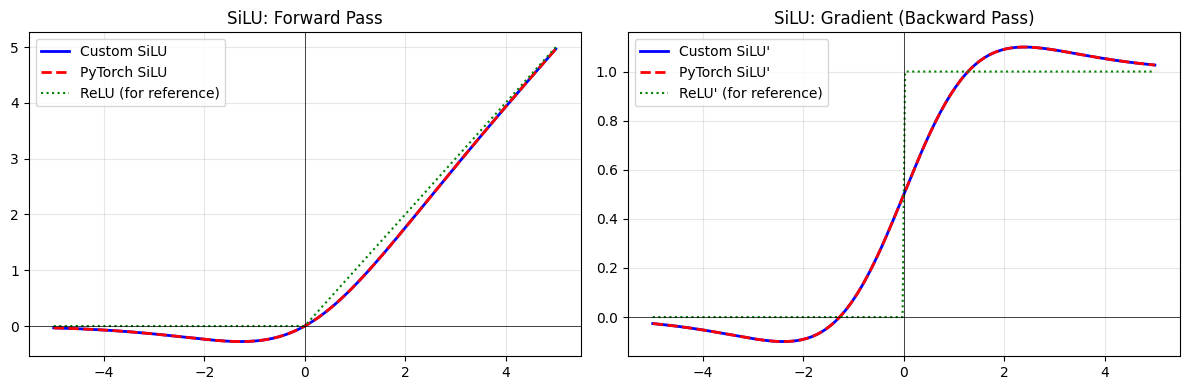


SiLU is smooth (unlike ReLU) and allows small negative values.
It's used in many modern architectures (e.g., SiLU = Swish in EfficientNet).


In [27]:
# Verify against PyTorch's built-in SiLU
x = torch.linspace(-5, 5, 200, requires_grad=False)

# Our custom SiLU
x_custom = x.clone().requires_grad_(True)
y_custom = custom_silu(x_custom)
y_custom.sum().backward()
grad_custom = x_custom.grad.clone()

# PyTorch built-in SiLU
x_builtin = x.clone().requires_grad_(True)
y_builtin = torch.nn.functional.silu(x_builtin)
y_builtin.sum().backward()
grad_builtin = x_builtin.grad.clone()

# Compare
print(f"Max forward difference:  {(y_custom - y_builtin).abs().max().item():.2e}")
print(f"Max gradient difference: {(grad_custom - grad_builtin).abs().max().item():.2e}")
print("Custom implementation matches PyTorch!")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x.numpy(), y_custom.detach().numpy(), 'b-', linewidth=2, label='Custom SiLU')
ax1.plot(x.numpy(), y_builtin.detach().numpy(), 'r--', linewidth=2, label='PyTorch SiLU')
ax1.plot(x.numpy(), torch.relu(x).numpy(), 'g:', linewidth=1.5, label='ReLU (for reference)')
ax1.set_title('SiLU: Forward Pass')
ax1.legend()
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

ax2.plot(x.numpy(), grad_custom.numpy(), 'b-', linewidth=2, label="Custom SiLU'")
ax2.plot(x.numpy(), grad_builtin.numpy(), 'r--', linewidth=2, label="PyTorch SiLU'")
relu_grad = (x > 0).float()
ax2.plot(x.numpy(), relu_grad.numpy(), 'g:', linewidth=1.5, label="ReLU' (for reference)")
ax2.set_title('SiLU: Gradient (Backward Pass)')
ax2.legend()
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nSiLU is smooth (unlike ReLU) and allows small negative values.")
print("It's used in many modern architectures (e.g., SiLU = Swish in EfficientNet).")


> **Connection to Notebook 1**: When you implemented `Value.__mul__`, you wrote:
> ```python
> def _backward():
>     self.grad += other.data * out.grad
>     other.grad += self.data * out.grad
> ```
> That's **exactly** what `SiLUFunction.backward()` does -- compute the local
> derivative and multiply by the incoming gradient (`grad_output`). The chain rule
> in action, whether you implement it yourself or use PyTorch's API.


---
## 8. Exercises

### Exercise 1: Gradient Computation

Compute the gradient of `f(x, y, z) = (x + 2y) * z**2` at `(x, y, z) = (1, 2, 3)`.

1. Compute analytically (by hand)
2. Verify with PyTorch autograd
3. Verify with finite differences: `(f(x+h) - f(x-h)) / 2h`


In [28]:
# Exercise 1: Gradient Computation
# Analytical:
#   f = (x + 2y) * z^2
#   df/dx = z^2
#   df/dy = 2*z^2
#   df/dz = 2*z*(x + 2y)
#
# At (1, 2, 3):
#   df/dx = 9
#   df/dy = 18
#   df/dz = 6 * 5 = 30

# --- SOLUTION ---
ex1_x = torch.tensor(1.0, requires_grad=True)
ex1_y = torch.tensor(2.0, requires_grad=True)
ex1_z = torch.tensor(3.0, requires_grad=True)

ex1_f = (ex1_x + 2*ex1_y) * ex1_z**2
ex1_f.backward()

print("Analytical vs PyTorch autograd:")
match_x = "MATCH" if abs(ex1_x.grad.item() - 9.0) < 1e-4 else "MISMATCH"
match_y = "MATCH" if abs(ex1_y.grad.item() - 18.0) < 1e-4 else "MISMATCH"
match_z = "MATCH" if abs(ex1_z.grad.item() - 30.0) < 1e-4 else "MISMATCH"
print(f"  df/dx = z^2         = 9.0  | PyTorch: {ex1_x.grad.item():.1f}  [{match_x}]")
print(f"  df/dy = 2z^2        = 18.0 | PyTorch: {ex1_y.grad.item():.1f} [{match_y}]")
print(f"  df/dz = 2z(x+2y)   = 30.0 | PyTorch: {ex1_z.grad.item():.1f} [{match_z}]")

# Finite differences verification
h = 1e-5
def f_val(xv, yv, zv):
    return (xv + 2*yv) * zv**2

x0, y0, z0 = 1.0, 2.0, 3.0
df_dx_fd = (f_val(x0+h, y0, z0) - f_val(x0-h, y0, z0)) / (2*h)
df_dy_fd = (f_val(x0, y0+h, z0) - f_val(x0, y0-h, z0)) / (2*h)
df_dz_fd = (f_val(x0, y0, z0+h) - f_val(x0, y0, z0-h)) / (2*h)

print(f"\nFinite differences (h={h}):")
print(f"  df/dx = {df_dx_fd:.6f}")
print(f"  df/dy = {df_dy_fd:.6f}")
print(f"  df/dz = {df_dz_fd:.6f}")


Analytical vs PyTorch autograd:
  df/dx = z^2         = 9.0  | PyTorch: 9.0  [MATCH]
  df/dy = 2z^2        = 18.0 | PyTorch: 18.0 [MATCH]
  df/dz = 2z(x+2y)   = 30.0 | PyTorch: 30.0 [MATCH]

Finite differences (h=1e-05):
  df/dx = 9.000000
  df/dy = 18.000000
  df/dz = 30.000000


### Exercise 2: ReLU vs Sigmoid Deep Network

Build two identical 8-layer MLPs for moons classification -- one with ReLU,
one with Sigmoid. Train both for 500 epochs. Compare:
- Final accuracy
- Gradient magnitudes in the first layer
- Training speed

This demonstrates **② ReLU changed everything**.


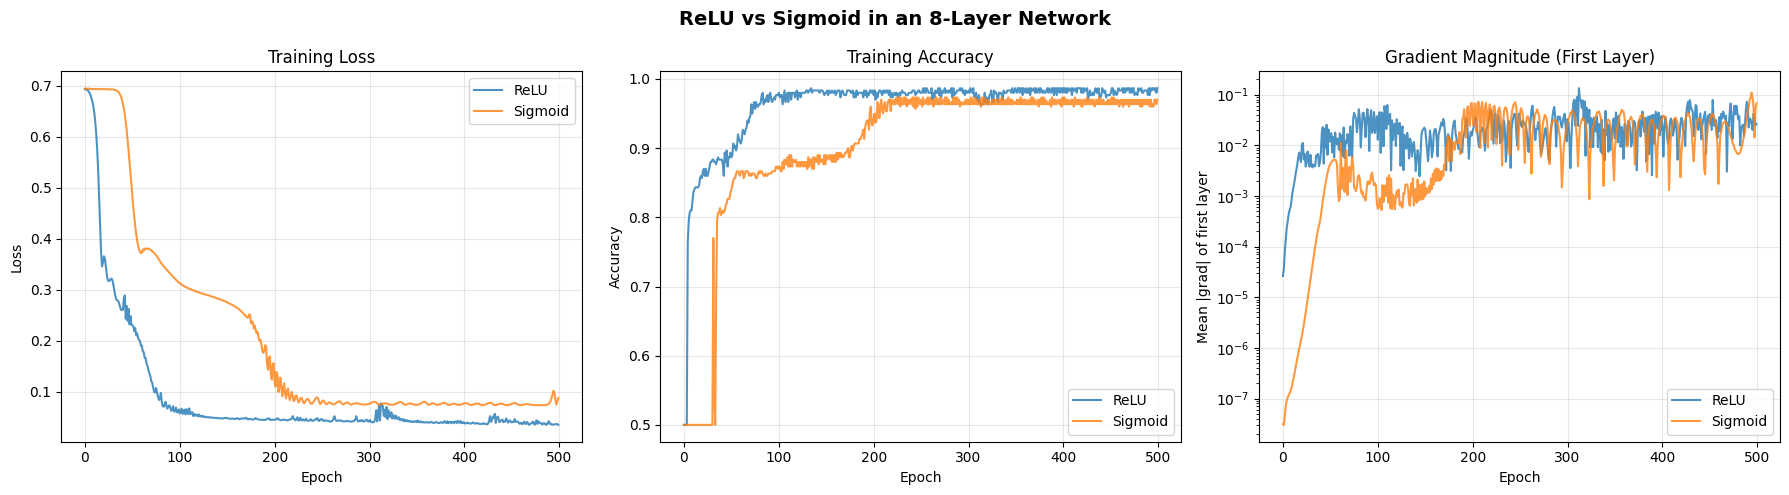

Final accuracy -- ReLU: 98.67%, Sigmoid: 97.00%
ReLU trains faster and achieves better accuracy in deep networks!


In [29]:
# Exercise 2: ReLU vs Sigmoid in deep networks

# --- SOLUTION ---
# Re-create moons data (in case variables were overwritten by previous exercises)
X_np_ex2, y_np_ex2 = make_moons(n_samples=300, noise=0.2, random_state=42)
X_ex2 = torch.tensor(X_np_ex2, dtype=torch.float32)
y_ex2 = torch.tensor(y_np_ex2, dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)

def make_deep_net(activation):
    """Build an 8-layer MLP with the given activation."""
    layers = []
    dims = [2, 16, 16, 16, 16, 16, 16, 16, 1]
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:  # no activation after last layer
            layers.append(activation())
    return nn.Sequential(*layers)

relu_net = make_deep_net(nn.ReLU)
sigmoid_net = make_deep_net(nn.Sigmoid)

relu_opt = optim.Adam(relu_net.parameters(), lr=0.01)
sigmoid_opt = optim.Adam(sigmoid_net.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

relu_losses, sigmoid_losses = [], []
relu_accs, sigmoid_accs = [], []
relu_grads_first, sigmoid_grads_first = [], []

for epoch in range(500):
    for net, opt, losses_list, accs_list, grads_list in [
        (relu_net, relu_opt, relu_losses, relu_accs, relu_grads_first),
        (sigmoid_net, sigmoid_opt, sigmoid_losses, sigmoid_accs, sigmoid_grads_first)
    ]:
        logits = net(X_ex2)
        loss = loss_fn(logits, y_ex2)
        opt.zero_grad()
        loss.backward()
        opt.step()

        losses_list.append(loss.item())
        with torch.no_grad():
            acc = ((torch.sigmoid(logits) > 0.5).float() == y_ex2).float().mean().item()
        accs_list.append(acc)

        # Record gradient magnitude of first layer
        first_weight_grad = list(net.parameters())[0].grad
        if first_weight_grad is not None:
            grads_list.append(first_weight_grad.abs().mean().item())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(relu_losses, label='ReLU', alpha=0.8)
axes[0].plot(sigmoid_losses, label='Sigmoid', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

axes[1].plot(relu_accs, label='ReLU', alpha=0.8)
axes[1].plot(sigmoid_accs, label='Sigmoid', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()

axes[2].plot(relu_grads_first, label='ReLU', alpha=0.8)
axes[2].plot(sigmoid_grads_first, label='Sigmoid', alpha=0.8)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Mean |grad| of first layer')
axes[2].set_title('Gradient Magnitude (First Layer)')
axes[2].set_yscale('log')
axes[2].legend()

plt.suptitle('ReLU vs Sigmoid in an 8-Layer Network', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Final accuracy -- ReLU: {relu_accs[-1]:.2%}, Sigmoid: {sigmoid_accs[-1]:.2%}")
print(f"ReLU trains faster and achieves better accuracy in deep networks!")


### Exercise 3: Custom Autograd -- Implement "Leaky ReLU"

Implement Leaky ReLU as a custom `torch.autograd.Function`:

$$\text{LeakyReLU}(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha x & \text{otherwise} \end{cases}$$

where $\alpha = 0.01$.

Then:
1. Compare output with `torch.nn.functional.leaky_relu`
2. Plot the function and its gradient


Max forward difference:  0.00e+00
Max gradient difference: 0.00e+00
Custom Leaky ReLU matches PyTorch!


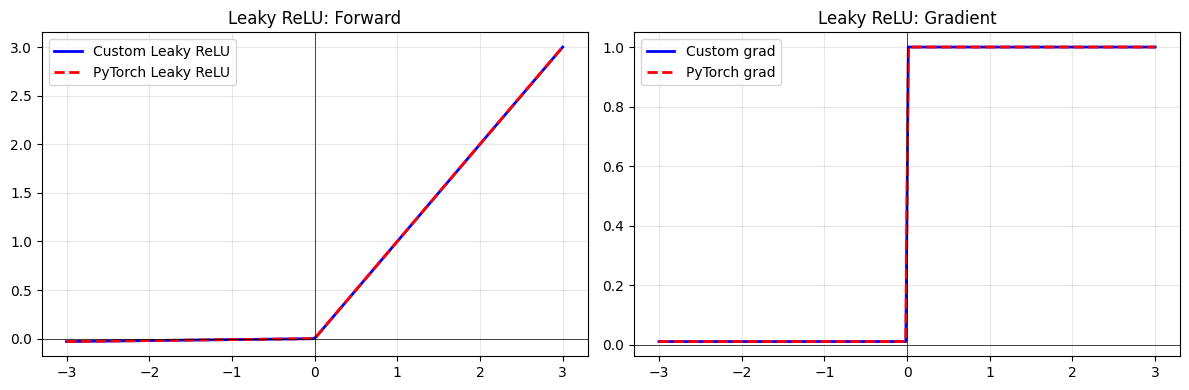


Leaky ReLU fixes the 'dying ReLU' problem:
neurons with x<0 still get a small gradient (alpha=0.01).


In [30]:
# Exercise 3: Custom Leaky ReLU

# --- SOLUTION ---
class LeakyReLUFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha=0.01):
        ctx.save_for_backward(x)
        ctx.alpha = alpha
        return torch.where(x > 0, x, alpha * x)

    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        alpha = ctx.alpha
        grad_input = grad_output * torch.where(
            x > 0, torch.ones_like(x), alpha * torch.ones_like(x)
        )
        return grad_input, None  # None for alpha (not a tensor)

def custom_leaky_relu(x, alpha=0.01):
    return LeakyReLUFunction.apply(x, alpha)

# Verify
x = torch.linspace(-3, 3, 200)
x_custom = x.clone().requires_grad_(True)
y_custom = custom_leaky_relu(x_custom)
y_custom.sum().backward()

x_builtin = x.clone().requires_grad_(True)
y_builtin = torch.nn.functional.leaky_relu(x_builtin, 0.01)
y_builtin.sum().backward()

print(f"Max forward difference:  {(y_custom - y_builtin).abs().max().item():.2e}")
print(f"Max gradient difference: {(x_custom.grad - x_builtin.grad).abs().max().item():.2e}")
print("Custom Leaky ReLU matches PyTorch!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(x.numpy(), y_custom.detach().numpy(), 'b-', linewidth=2, label='Custom Leaky ReLU')
ax1.plot(x.numpy(), y_builtin.detach().numpy(), 'r--', linewidth=2, label='PyTorch Leaky ReLU')
ax1.set_title('Leaky ReLU: Forward')
ax1.legend()
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

ax2.plot(x.numpy(), x_custom.grad.numpy(), 'b-', linewidth=2, label="Custom grad")
ax2.plot(x.numpy(), x_builtin.grad.numpy(), 'r--', linewidth=2, label="PyTorch grad")
ax2.set_title('Leaky ReLU: Gradient')
ax2.legend()
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nLeaky ReLU fixes the 'dying ReLU' problem:")
print("neurons with x<0 still get a small gradient (alpha=0.01).")


---
## Summary

| Concept | Notebook 1 (Pure Python) | This Notebook (PyTorch) |
|---------|--------------------------|------------------------|
| **Data structure** | `Value` (scalar) | `torch.Tensor` (any shape) |
| **Autograd** | Manual `_backward` closures | Automatic via `requires_grad` |
| **Gradient computation** | `loss.backward()` + topo sort | `loss.backward()` (same!) |
| **Network building** | `Neuron`, `Layer`, `MLP` classes | `nn.Module`, `nn.Linear` |
| **Training loop** | Manual: zero -> forward -> backward -> update | Same pattern with optimizer |
| **Activation** | `relu()` method on Value | `nn.ReLU()` module |

### Curriculum Points Covered

> **① Universal Approximation Theorem** (§6)
>
> A single hidden layer with enough neurons can approximate any continuous function.
> Depth makes this more parameter-efficient -- deep networks compose features hierarchically.

> **② ReLU Changed Everything** (§4, §8 Exercise 2)
>
> Sigmoid/tanh gradients vanish in deep networks (max derivative 0.25 for sigmoid).
> ReLU gradient is exactly 0 or 1 -- no vanishing gradient problem.
> This is why virtually all modern architectures use ReLU or its variants (Leaky ReLU, SiLU, GELU).

> **⑤ Backpropagation = Chain Rule** (§3, §7)
>
> Whether you implement it yourself (Notebook 1) or let PyTorch do it,
> backprop is the same algorithm: walk the computation graph in reverse,
> multiply local derivatives by incoming gradients (the chain rule).
> PyTorch just does it automatically, for tensors of any shape, on any device.

### What's Next

In the next notebook, we'll tackle **CNNs, training recipes, and overparameterization** --
building on everything you've learned here to train real image classifiers.
